# Agentic AI MCP - Client Only

This notebook connects to a remote MCP server and runs agentic workflows.
The MCP server should be running on another machine (see `quickstart_server.ipynb`).

## Step 1: Setup

In [1]:
# install if needed
# !uv pip install agentic-ai-mcp==0.6.4

import agentic_ai_mcp

print(f"Version: {agentic_ai_mcp.__version__}")

Version: 0.6.4


## Step 2: Make Sure To Have A Valid API_KEY

The LLM runs on this machine, so you need the API key here.
- For **Anthropic** (default): Set `ANTHROPIC_API_KEY`
- For **OpenAI**: Set `OPENAI_API_KEY`

In [ ]:
import os

from dotenv import load_dotenv

load_dotenv()

# check for API keys
if os.getenv("ANTHROPIC_API_KEY"):
    print("ANTHROPIC_API_KEY is set")
else:
    print("WARNING: ANTHROPIC_API_KEY not found")

if os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY is set")
else:
    print("INFO: OPENAI_API_KEY not found (optional, only needed for OpenAI provider)")

## Step 3: Connect to MCP Server and Create AgenticAIClient

Use `mcp_url` for a single server, or `mcp_urls` for multiple servers.

In [3]:
from agentic_ai_mcp import AgenticAIClient

# Option A: connect to a single MCP server (backward compatible)
MCP_SERVER_URL = "http://127.0.0.1:8888/mcp"
client = AgenticAIClient(mcp_url=MCP_SERVER_URL, verbose=True)

# Option B: connect to multiple MCP servers
# client = AgenticAIClient(
#     mcp_urls=[
#         "http://server1:8888/mcp",  # e.g. math tools
#         "http://server2:9999/mcp",  # e.g. greeting tools
#     ],
#     verbose=True,
# )

# if you want to use OpenAI model, change accordingly, e.g. -
# client = AgenticAIClient(mcp_url=MCP_SERVER_URL, provider="openai", model="gpt-4o-mini")

# you can also pass the API key directly:
# client = AgenticAIClient(mcp_url=MCP_SERVER_URL, api_key="sk-...")

print(f"Client configured to connect to: {client.mcp_urls}")

Client configured to connect to: ['http://127.0.0.1:8888/mcp']


## Step 4a: Run Agent (Simple Task)

In [4]:
result = await client.run("Calculate 2+1, then use the result as the number of times to greet 'Alice'.")
print()
print(">>>")
print()
print(result)

Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['add', 'multiply', 'greet', 'do_imaging']

PROMPT: Calculate 2+1, then use the result as the number of times to greet 'Alice'.



/mnt/jawad_cnms_s1/jawad_server/code/20260221_code_agentic_ai/agentic-ai-mcp/src/agentic_ai_mcp/client.py:223: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  self._agent = create_react_agent(


STEP 1: add({'a': 2, 'b': 1})
  → 3

STEP 2: greet({'name': 'Alice', 'times': 3})
  → Hello, Alice! Hello, Alice! Hello, Alice! 

RESULT: Perfect! Here are the results:
- **2 + 1 = 3**
- **Greeting Alice 3 times:** Hello, Alice! Hello, Alice! Hello, Alice!


>>>

Perfect! Here are the results:
- **2 + 1 = 3**
- **Greeting Alice 3 times:** Hello, Alice! Hello, Alice! Hello, Alice!


## Step 4b: Run Agent (Simple Task with Image Transfer over Protocol)

The server generates an image which is automatically displayed in Jupyter.


PROMPT: Generate a 100x100 random image using do_imaging

STEP 1: do_imaging({'width': 100, 'height': 100})
  → Generated a 100x100 random image

RESULT: Perfect! I've generated a 100x100 random image using the do_imaging function. The image has been created with the specified dimensions of 100 pixels by 100 pixels.



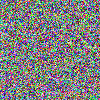

[Displayed 100x100 image]

>>>

Perfect! I've generated a 100x100 random image using the do_imaging function. The image has been created with the specified dimensions of 100 pixels by 100 pixels.


In [5]:
result = await client.run("Generate a 100x100 random image using do_imaging")
print()
print(">>>")
print()
print(result)

## Step 4c: Run Agent (Complex Task with Planning)


PLANNING MODE
TASK: Calculate (((0+2) x (1+1)) + ((0+1) x (1+1))) + 250, then use the result as the height and width of an image to do imaging.

PLAN:
  1. Use add(a=0, b=2) to calculate the first inner sum
  2. Use add(a=1, b=1) to calculate the second inner sum
  3. Use multiply(a=result from step 1, b=result from step 2) to get the first product
  4. Use add(a=0, b=1) to calculate the third inner sum
  5. Use multiply(a=result from step 4, b=result from step 2) to get the second product
  6. Use add(a=result from step 3, b=result from step 5) to sum the two products
  7. Use add(a=result from step 6, b=250) to calculate the final result
  8. Use do_imaging(width=result from step 7, height=result from step 7) to generate an image with dimensions based on the calculated value

EXECUTING STEP 1/8: Use add(a=0, b=2) to calculate the first inner sum
----------------------------------------


/mnt/jawad_cnms_s1/jawad_server/code/20260221_code_agentic_ai/agentic-ai-mcp/src/agentic_ai_mcp/workflows/planning.py:151: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  step_agent = create_react_agent(llm, tools)


  TOOL CALL 1: add({'a': 0, 'b': 2})
    → 2
  AI RESPONSE: The first inner sum is **2**. Using add(a=0, b=2), we get 0 + 2 = 2.
----------------------------------------
STEP 1 COMPLETE

EXECUTING STEP 2/8: Use add(a=1, b=1) to calculate the second inner sum
----------------------------------------
  TOOL CALL 1: add({'a': 1, 'b': 1})
    → 2
  AI RESPONSE: **Step 2: The second inner sum is 2.** Using add(a=1, b=1), we get 1 + 1 = 2.

So far we have:
- First inner sum: 2
- Second inner sum: 2
----------------------------------------
STEP 2 COMPLETE

EXECUTING STEP 3/8: Use multiply(a=result from step 1, b=result from step 2) to get the first product
----------------------------------------
  TOOL CALL 1: multiply({'a': 2, 'b': 2})
    → 4
  AI RESPONSE: Perfect! 

**Step 3: The first product is 4.**

Using multiply(a=2, b=2), we get 2 × 2 = **4**

So now we have:
- First inner sum: 2
- Second inner sum: 2
- **First product: 4**
----------------------------------------
STEP 3 COMPLETE



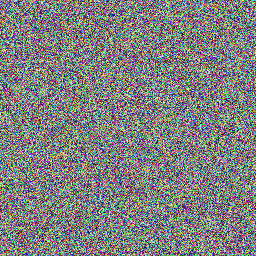

[Displayed 256x256 image]

>>>

# Final Response

## Task Completion Summary

**Original Task:** Calculate (((0+2) × (1+1)) + ((0+1) × (1+1))) + 250, then use the result as the height and width of an image.

## Calculation Results

Following the multi-step arithmetic:
- (0+2) = 2
- (1+1) = 2
- 2 × 2 = 4
- (0+1) = 1
- (1+1) = 2
- 1 × 2 = 2
- 4 + 2 = 6
- **6 + 250 = 256**

## Final Outcome

✅ **Calculation Result: 256**

✅ **Image Generated: 256×256 pixel random image**

The mathematical expression evaluated to **256**, which was successfully used as both the width and height dimensions to generate a square image with those exact specifications.


In [6]:
result = await client.run_with_planning("Calculate (((0+2) x (1+1)) + ((0+1) x (1+1))) + 250, then use the result as the height and width of an image to do imaging.")
print()
print(">>>")
print()
print(result)

---

# Multi-Agent Orchestration

The examples below show how to use `AgenticAIOrchestrator` to coordinate multiple agents.
Each agent can have a **role** (to shape its behavior) and a **tool_filter** (to limit which tools it loads).

## Step 5a: Sequential Orchestration

Agents run one after another. Each agent sees the previous agent's output as context.

In [4]:
from agentic_ai_mcp import AgenticAIOrchestrator

# create specialized agents with roles and tool filters
math_agent = AgenticAIClient(
    mcp_url=MCP_SERVER_URL,
    role="mathematician",
    tool_filter=["add", "multiply"],  # only math tools
    verbose=True,
)

greeter_agent = AgenticAIClient(
    mcp_url=MCP_SERVER_URL,
    role="greeter",
    tool_filter=["greet"],  # only greeting tool
    verbose=True,
)

# sequential: math_agent runs first, greeter_agent sees its output
orchestrator_seq = AgenticAIOrchestrator(
    clients=[math_agent, greeter_agent],
    flow_type="sequential",
)
print('@@@@@@@@@@@@@@@@@@@@@@@')

result = await orchestrator_seq.run(
    "Calculate 2+3, then greet 'Alice' that many times."
)
print()
print(">>>")
print()
print(result)

@@@@@@@@@@@@@@@@@@@@@@@
Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['add', 'multiply']

PROMPT: You are a mathematician.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Calculate 2+3, then greet 'Alice' that many times.



/mnt/jawad_cnms_s1/jawad_server/code/20260221_code_agentic_ai/agentic-ai-mcp/src/agentic_ai_mcp/client.py:217: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  self._agent = create_react_agent(


STEP 1: add({'a': 2, 'b': 3})
  → 5

RESULT: Great! 2+3 = 5.

However, I can only accomplish the mathematical part of your task. I don't have a tool available to greet Alice - that would require a different capability. But I can tell you that based on the result, you should greet Alice 5 times!

Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['greet']

PROMPT: You are a greeter.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Previous agent results:
Great! 2+3 = 5.

However, I can only accomplish the mathematical part of your task. I don't have a tool available to greet Alice - that would require a different capability. But I can tell you that based on the result, you should greet Alice 5 times!

Calculate 2+3, then greet 'Alice' that many times.

STEP 1: greet({'name': 'Alice', 'times': 5})
  → Hello, Alice! Hello, Alice! Hello, Alice! Hello, Alice! Hello, Alice! 

RESULT: Pe

## Step 5b: Parallel Orchestration

Agents run concurrently and their results are combined.

In [5]:
# Two agents work on the same prompt in parallel
agent_a = AgenticAIClient(
    mcp_url=MCP_SERVER_URL,
    role="adder",
    tool_filter=["add"],
    verbose=True,
)

agent_b = AgenticAIClient(
    mcp_url=MCP_SERVER_URL,
    role="multiplier",
    tool_filter=["multiply"],
    verbose=True,
)

orchestrator_par = AgenticAIOrchestrator(
    clients=[agent_a, agent_b],
    flow_type="parallel",
)

result = await orchestrator_par.run(
    "Compute using your available tool: what is 4 and 5?"
)
print()
print(">>>")
print()
print(result)

Loading tools from: http://127.0.0.1:8888/mcp
Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['add']

PROMPT: You are a adder.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Compute using your available tool: what is 4 and 5?

Loaded tools: ['multiply']

PROMPT: You are a multiplier.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Compute using your available tool: what is 4 and 5?

STEP 1: add({'a': 4, 'b': 5})
  → 9

RESULT: 4 and 5 equals **9**.

STEP 1: multiply({'a': 4, 'b': 5})
  → 20

RESULT: 4 multiplied by 5 is **20**.


>>>

[adder]
4 and 5 equals **9**.

[multiplier]
4 multiplied by 5 is **20**.


## Step 5c: Orchestration with Synthesizer

A synthesizer agent runs last to combine all agent results into a single final output.

In [6]:
synth_agent = AgenticAIClient(
    mcp_url=MCP_SERVER_URL,
    role="synthesizer",
    verbose=True,
)

orchestrator_synth = AgenticAIOrchestrator(
    clients=[agent_a, agent_b],
    flow_type="parallel",
    synthesizer=synth_agent,
)

result = await orchestrator_synth.run(
    "Compute using your available tool: what is 4 and 5?"
)
print()
print(">>>")
print()
print(result)


PROMPT: You are a adder.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Compute using your available tool: what is 4 and 5?


PROMPT: You are a multiplier.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Compute using your available tool: what is 4 and 5?

STEP 1: multiply({'a': 4, 'b': 5})
  → 20

RESULT: 4 multiplied by 5 is **20**.

STEP 1: add({'a': 4, 'b': 5})
  → 9

RESULT: 4 and 5 equals **9**.

Loading tools from: http://127.0.0.1:8888/mcp
Loaded tools: ['add', 'multiply', 'greet', 'do_imaging']

PROMPT: You are a synthesizer.

Only perform the parts of the task that can be accomplished with your available tools. Do not attempt parts that require tools you do not have.

Previous agent results:
[adder]
4 and 5 equals **9**.

[multiplier]
4 multiplied by 5 is **20**.

Compute using you

## Step 5d: Shared State

Use `SharedState` to share data between agents during orchestration. After execution, agent results are also stored in shared state.

In [ ]:
from agentic_ai_mcp import SharedState

# Create shared state with initial data
state = SharedState({"project": "demo"})

orchestrator_state = AgenticAIOrchestrator(
    clients=[math_agent, greeter_agent],
    flow_type="sequential",
    shared_state=state,
)

result = await orchestrator_state.run("Add 10+20, then greet 'Bob' once.")
print()
print(">>>")
print()
print(result)

# Inspect shared state after execution
print()
print("=== Shared State ===")
print(f"Initial data preserved: project = {state.get('project')}")
print(f"Agent results stored: {len(state.get('agent_results', []))} agents ran")
print(f"Full state: {state.to_dict()}")

## Step 5e: Orchestration with Planning

The orchestrator also supports `run_with_planning()` which uses the planning workflow on each agent.

In [ ]:
result = await orchestrator_seq.run_with_planning(
    "Calculate ((2+3) x (1+1)), then greet 'Charlie' that many times."
)
print()
print(">>>")
print()
print(result)